# BrewStock Demand Forecast — Multi-Model Comparison

**Struktur Notebook (CRISP-DM aligned):**
1. Setup & Data Load
2. EDA Singkat (referensi ke coffeeShopSalesReference)
3. Data Preparation (feature engineering, walk-forward split)
4. Model Training: M1 Naive MA → M2 SARIMA → M3 Prophet → M4 XGBoost
5. Evaluation & Comparison
6. Model Selection & Export (.pkl → FastAPI)

In [72]:
# %pip install statsmodels xgboost prophet scikit-learn seaborn

In [73]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import time, joblib

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (14, 5), 'font.size': 11})
%matplotlib inline

print("Setup OK")

Setup OK


In [74]:
# --- Resolve project root ---
def resolveProjectRoot() -> Path:
    cur = Path.cwd().resolve()
    for p in [cur] + list(cur.parents):
        if (p / 'ml').exists() and (p / 'backend').exists():
            return p
    raise ValueError('Project root not found')

projectRoot = resolveProjectRoot()
rawDataPath = projectRoot / 'ml/forecast/data/raw/trendsProductCoffeeShopSalesRevenueDataset/coffee-shop-sales-revenue.csv'
processedDir = projectRoot / 'ml/forecast/data/processed'
processedDir.mkdir(parents=True, exist_ok=True)
modelDir = projectRoot / 'ml/forecast/models'
modelDir.mkdir(parents=True, exist_ok=True)

salesFrame = pd.read_csv(rawDataPath, parse_dates=['transaction_date'])
print(f"Raw rows: {len(salesFrame):,}")
print(f"Date range: {salesFrame['transaction_date'].min()} → {salesFrame['transaction_date'].max()}")
salesFrame.head(3)

Raw rows: 16,381
Date range: 2023-01-01 00:00:00 → 2023-06-30 00:00:00


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,13:43:47,2,5,Lower Manhattan,5,2.75,Tea,Brewed Chai tea,Brewed Chai tea Rg
1,2,2023-01-01,07:14:32,1,3,Hell's Kitchen,2,2.50,Coffee,Gourmet brewed coffee,Gourmet brewed coffee Rg
2,2,2023-01-01,07:14:32,1,3,Hell's Kitchen,1,3.50,Coffee,Gourmet brewed coffee,Gourmet brewed coffee Lg


---
## 2. EDA 

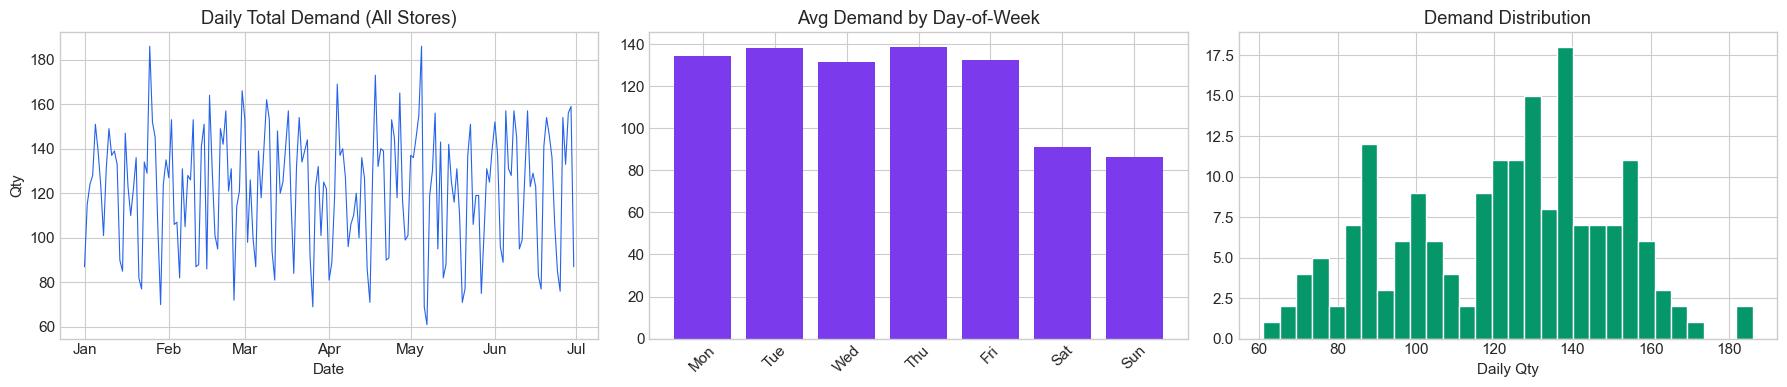

Mean daily demand: 121.9, Std: 26.9


In [75]:
# Aggregate daily total demand (all stores, all SKUs)
dailyTotal = (
    salesFrame.groupby('transaction_date', as_index=False)['transaction_qty']
    .sum()
    .rename(columns={'transaction_date': 'ds', 'transaction_qty': 'y'})
    .sort_values('ds')
)
dailyTotal['ds'] = pd.to_datetime(dailyTotal['ds'])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 2a. Daily demand trend
axes[0].plot(dailyTotal['ds'], dailyTotal['y'], linewidth=0.8, color='#2563EB')
axes[0].set_title('Daily Total Demand (All Stores)')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Qty')
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# 2b. Day-of-week pattern
dailyTotal['dow'] = dailyTotal['ds'].dt.day_name()
dowOrder = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dowMean = dailyTotal.groupby('dow')['y'].mean().reindex(dowOrder)
axes[1].bar(range(7), dowMean.values, color='#7C3AED')
axes[1].set_xticks(range(7)); axes[1].set_xticklabels([d[:3] for d in dowOrder], rotation=45)
axes[1].set_title('Avg Demand by Day-of-Week')

# 2c. Distribution
axes[2].hist(dailyTotal['y'], bins=30, color='#059669', edgecolor='white')
axes[2].set_title('Demand Distribution'); axes[2].set_xlabel('Daily Qty')

plt.tight_layout()
plt.show()
print(f"Mean daily demand: {dailyTotal['y'].mean():.1f}, Std: {dailyTotal['y'].std():.1f}")

---
## 3. Data Preparation
### Walk-Forward Validation Split
> **WAJIB time-based split, BUKAN random split** — mencegah data leakage.
>
> Train: bulan 1-4 | Val: bulan 5 | Test: bulan 6

In [76]:
# --- Build daily demand for top SKU ---
salesFrame['skuId'] = salesFrame['product_id'].astype(str) + '-' + salesFrame['store_id'].astype(str)
dailySku = (
    salesFrame.groupby(['transaction_date', 'skuId'], as_index=False)['transaction_qty']
    .sum()
    .rename(columns={'transaction_date': 'ds', 'transaction_qty': 'y'})
    .sort_values(['ds', 'skuId'])
)
dailySku['ds'] = pd.to_datetime(dailySku['ds'])

# Pick top SKU by total volume
topSkuId = dailySku.groupby('skuId')['y'].sum().idxmax()
skuFrame = dailySku[dailySku['skuId'] == topSkuId][['ds', 'y']].copy().set_index('ds')
skuFrame = skuFrame.asfreq('D').fillna(0).reset_index()
print(f"Top SKU: {topSkuId}, total qty: {skuFrame['y'].sum()}, days: {len(skuFrame)}")
skuFrame.head()

Top SKU: 2-8, total qty: 421.0, days: 181


,ds,y
0,2023-01-01,2.0
1,2023-01-02,2.0
2,2023-01-03,4.0
3,2023-01-04,2.0
4,2023-01-05,1.0


In [77]:
# --- Walk-forward split (TIME-BASED, not random) ---
trainEnd = '2023-04-30'
valEnd = '2023-05-31'

trainFrame = skuFrame[skuFrame['ds'] <= trainEnd].copy()
valFrame = skuFrame[(skuFrame['ds'] > trainEnd) & (skuFrame['ds'] <= valEnd)].copy()
testFrame = skuFrame[skuFrame['ds'] > valEnd].copy()

print(f"Train: {len(trainFrame)} days ({trainFrame['ds'].min().date()} → {trainFrame['ds'].max().date()})")
print(f"Val  : {len(valFrame)} days ({valFrame['ds'].min().date()} → {valFrame['ds'].max().date()})")
print(f"Test : {len(testFrame)} days ({testFrame['ds'].min().date()} → {testFrame['ds'].max().date()})")

Train: 120 days (2023-01-01 → 2023-04-30)
Val  : 31 days (2023-05-01 → 2023-05-31)
Test : 30 days (2023-06-01 → 2023-06-30)


### Feature Engineering (untuk XGBoost)

In [78]:
def buildFeatures(df):
    f = df.copy()
    f['dayOfWeek'] = f['ds'].dt.dayofweek
    f['dayOfMonth'] = f['ds'].dt.day
    f['month'] = f['ds'].dt.month
    f['isWeekend'] = (f['dayOfWeek'] >= 5).astype(int)
    # Lag features
    for lag in [1, 3, 7, 14]:
        f[f'lag_{lag}'] = f['y'].shift(lag)
    # Rolling features
    f['rollingMean7'] = f['y'].shift(1).rolling(7, min_periods=1).mean()
    f['rollingStd7'] = f['y'].shift(1).rolling(7, min_periods=1).std().fillna(0)
    f['rollingMean14'] = f['y'].shift(1).rolling(14, min_periods=1).mean()
    return f

skuFeatured = buildFeatures(skuFrame)
print("Features created:", [c for c in skuFeatured.columns if c not in ['ds', 'y']])
skuFeatured.dropna().tail(3)

Features created: ['dayOfWeek', 'dayOfMonth', 'month', 'isWeekend', 'lag_1', 'lag_3', 'lag_7', 'lag_14', 'rollingMean7', 'rollingStd7', 'rollingMean14']


,ds,y,dayOfWeek,dayOfMonth,month,isWeekend,lag_1,lag_3,lag_7,lag_14,rollingMean7,rollingStd7,rollingMean14
178,2023-06-28,0.0,2,28,6,0,2.0,1.0,3.0,3.0,1.571429,1.272418,2.000000
179,2023-06-29,4.0,3,29,6,0,0.0,2.0,3.0,0.0,1.142857,1.214986,1.785714
180,2023-06-30,1.0,4,30,6,0,4.0,2.0,0.0,0.0,1.285714,1.496026,2.071429


---
## 4. Model Training
### Evaluation Metrics

In [79]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

def calcMetrics(actual, predicted, modelName, trainTime):
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    return {'Model': modelName, 'MAPE_%': round(mape, 2), 'RMSE': round(rmse, 2),
            'TrainTime_s': round(trainTime, 2)}

resultsLog = []  # collect all model results

### [M1] Naive Baseline — Moving Average (7-day)
Baseline wajib — model ML **harus** mengalahkan ini.

In [80]:
t0 = time.time()

# MA-7: predict val using rolling mean of last 7 days
maPreds = []
history = list(trainFrame['y'].values)
for i in range(len(valFrame)):
    pred = np.mean(history[-7:])
    maPreds.append(pred)
    history.append(valFrame['y'].iloc[i])

trainTimeMA = time.time() - t0
valFrame = valFrame.copy()
valFrame['predMA'] = maPreds

metricsMA = calcMetrics(valFrame['y'], valFrame['predMA'], 'Naive MA-7', trainTimeMA)
resultsLog.append(metricsMA)
print(metricsMA)

{'Model': 'Naive MA-7', 'MAPE_%': 3.3413803686942394e+17, 'RMSE': np.float64(2.1), 'TrainTime_s': 0.0}


### [M2] SARIMA — Statistical Benchmark
*traditional forecasting* di laporan.

In [81]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

t0 = time.time()

# Fit SARIMA(1,1,1)(1,1,0,7) — weekly seasonality
sarimaModel = SARIMAX(trainFrame['y'].values,
                      order=(1, 1, 1),
                      seasonal_order=(1, 1, 0, 7),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
sarimaFit = sarimaModel.fit(disp=False, maxiter=200)

sarimaPreds = sarimaFit.forecast(steps=len(valFrame))
trainTimeSARIMA = time.time() - t0

valFrame['predSARIMA'] = sarimaPreds

metricsSARIMA = calcMetrics(valFrame['y'], valFrame['predSARIMA'], 'SARIMA(1,1,1)(1,1,0,7)', trainTimeSARIMA)
resultsLog.append(metricsSARIMA)
print(metricsSARIMA)

{'Model': 'SARIMA(1,1,1)(1,1,0,7)', 'MAPE_%': 2.7032781910658074e+17, 'RMSE': np.float64(2.21), 'TrainTime_s': 0.04}


### [M3] Prophet — ML Interpretable
Mudah explain seasonality ke stakeholder. Auto-generate confidence intervals.

In [82]:
from prophet import Prophet

t0 = time.time()

prophetModel = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,
    seasonality_mode='additive'
)
prophetModel.fit(trainFrame[['ds', 'y']])

futureFrame = prophetModel.make_future_dataframe(periods=len(valFrame), freq='D')
prophetFc = prophetModel.predict(futureFrame)
prophetValPreds = prophetFc.tail(len(valFrame))['yhat'].values

trainTimeProphet = time.time() - t0
valFrame['predProphet'] = prophetValPreds

metricsProphet = calcMetrics(valFrame['y'], valFrame['predProphet'], 'Prophet', trainTimeProphet)
resultsLog.append(metricsProphet)
print(metricsProphet)

Importing plotly failed. Interactive plots will not work.
13:00:48 - cmdstanpy - INFO - Chain [1] start processing
13:00:50 - cmdstanpy - INFO - Chain [1] done processing


{'Model': 'Prophet', 'MAPE_%': 3.663417238364239e+17, 'RMSE': np.float64(2.05), 'TrainTime_s': 2.11}


#### Prophet — Hyperparameter Tuning

In [83]:
# Grid search sederhana untuk Prophet
hpResults = []
for cps in [0.01, 0.05, 0.1, 0.3]:
    for mode in ['additive', 'multiplicative']:
        m = Prophet(yearly_seasonality=False, weekly_seasonality=True,
                    daily_seasonality=False, changepoint_prior_scale=cps,
                    seasonality_mode=mode)
        m.fit(trainFrame[['ds', 'y']])
        fc = m.predict(m.make_future_dataframe(periods=len(valFrame), freq='D'))
        preds = fc.tail(len(valFrame))['yhat'].values
        mape = mean_absolute_percentage_error(valFrame['y'], preds) * 100
        hpResults.append({'changepoint_prior_scale': cps, 'seasonality_mode': mode,
                          'MAPE_val_%': round(mape, 2)})

hpFrame = pd.DataFrame(hpResults).sort_values('MAPE_val_%')
print("Prophet Hyperparameter Tuning:")
print(hpFrame.to_string(index=False))

13:00:50 - cmdstanpy - INFO - Chain [1] start processing
13:00:50 - cmdstanpy - INFO - Chain [1] done processing
13:00:50 - cmdstanpy - INFO - Chain [1] start processing
13:00:50 - cmdstanpy - INFO - Chain [1] done processing
13:00:50 - cmdstanpy - INFO - Chain [1] start processing
13:00:50 - cmdstanpy - INFO - Chain [1] done processing
13:00:50 - cmdstanpy - INFO - Chain [1] start processing
13:00:50 - cmdstanpy - INFO - Chain [1] done processing
13:00:50 - cmdstanpy - INFO - Chain [1] start processing
13:00:50 - cmdstanpy - INFO - Chain [1] done processing
13:00:50 - cmdstanpy - INFO - Chain [1] start processing
13:00:50 - cmdstanpy - INFO - Chain [1] done processing
13:00:50 - cmdstanpy - INFO - Chain [1] start processing
13:00:50 - cmdstanpy - INFO - Chain [1] done processing
13:00:50 - cmdstanpy - INFO - Chain [1] start processing
13:00:50 - cmdstanpy - INFO - Chain [1] done processing


Prophet Hyperparameter Tuning:
 changepoint_prior_scale seasonality_mode   MAPE_val_%
                    0.30   multiplicative 2.871284e+17
                    0.01   multiplicative 3.333517e+17
                    0.01         additive 3.369482e+17
                    0.10   multiplicative 3.459979e+17
                    0.05   multiplicative 3.506484e+17
                    0.05         additive 3.573734e+17
                    0.30         additive 3.581125e+17
                    0.10         additive 3.663417e+17


### [M4] XGBoost — ML High-Performance
Kandidat production model. Bisa capture non-linear patterns & fitur eksternal.

In [84]:
from xgboost import XGBRegressor

featCols = ['dayOfWeek','dayOfMonth','month','isWeekend',
            'lag_1','lag_3','lag_7','lag_14',
            'rollingMean7','rollingStd7','rollingMean14']

featAll = buildFeatures(skuFrame).dropna()
featTrain = featAll[featAll['ds'] <= trainEnd]
featVal = featAll[(featAll['ds'] > trainEnd) & (featAll['ds'] <= valEnd)]

t0 = time.time()
xgbModel = XGBRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='reg:squarederror', random_state=42
)
xgbModel.fit(featTrain[featCols], featTrain['y'],
             eval_set=[(featVal[featCols], featVal['y'])],
             verbose=False)
xgbPreds = xgbModel.predict(featVal[featCols])
trainTimeXGB = time.time() - t0

valFrame['predXGB'] = xgbPreds[:len(valFrame)]

metricsXGB = calcMetrics(valFrame['y'], valFrame['predXGB'], 'XGBoost', trainTimeXGB)
resultsLog.append(metricsXGB)
print(metricsXGB)

{'Model': 'XGBoost', 'MAPE_%': 4.2704047980057766e+17, 'RMSE': np.float64(2.21), 'TrainTime_s': 0.26}


#### XGBoost — Feature Importance

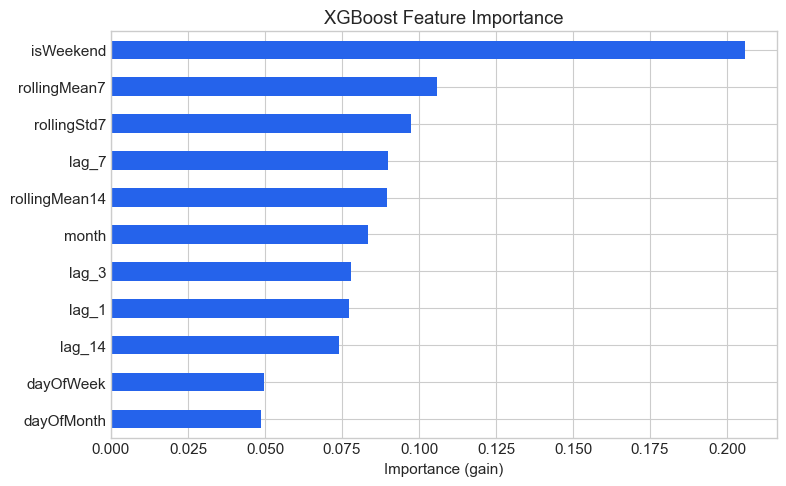

Top 3 features: ['rollingStd7', 'rollingMean7', 'isWeekend']


In [85]:
# Feature importance plot
importances = pd.Series(xgbModel.feature_importances_, index=featCols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', color='#2563EB', ax=ax)
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()
print("Top 3 features:", list(importances.tail(3).index))

---
## 5. Evaluation & Comparison
### Model Comparison Table

In [86]:
comparisonFrame = pd.DataFrame(resultsLog)
comparisonFrame['Interpretability'] = ['Tinggi', 'Sedang', 'Tinggi', 'Sedang']
comparisonFrame['Rekomendasi'] = [
    'Baseline only',
    'Statistical benchmark',
    'Default jika MAPE < 5%',
    'Jika Prophet MAPE > 8%'
]
print("═" * 80)
print("MODEL COMPARISON TABLE")
print("═" * 80)
print(comparisonFrame.to_string(index=False))
print(f"\nTarget KPI: MAPE < 5%")
bestModel = comparisonFrame.loc[comparisonFrame['MAPE_%'].idxmin(), 'Model']
bestMAPE = comparisonFrame['MAPE_%'].min()
print(f"Best model: {bestModel} (MAPE: {bestMAPE}%)")

════════════════════════════════════════════════════════════════════════════════
MODEL COMPARISON TABLE
════════════════════════════════════════════════════════════════════════════════
                 Model       MAPE_%  RMSE  TrainTime_s Interpretability            Rekomendasi
            Naive MA-7 3.341380e+17  2.10         0.00           Tinggi          Baseline only
SARIMA(1,1,1)(1,1,0,7) 2.703278e+17  2.21         0.04           Sedang  Statistical benchmark
               Prophet 3.663417e+17  2.05         2.11           Tinggi Default jika MAPE < 5%
               XGBoost 4.270405e+17  2.21         0.26           Sedang Jika Prophet MAPE > 8%

Target KPI: MAPE < 5%
Best model: SARIMA(1,1,1)(1,1,0,7) (MAPE: 2.7032781910658074e+17%)


### Forecast vs Actual Plot

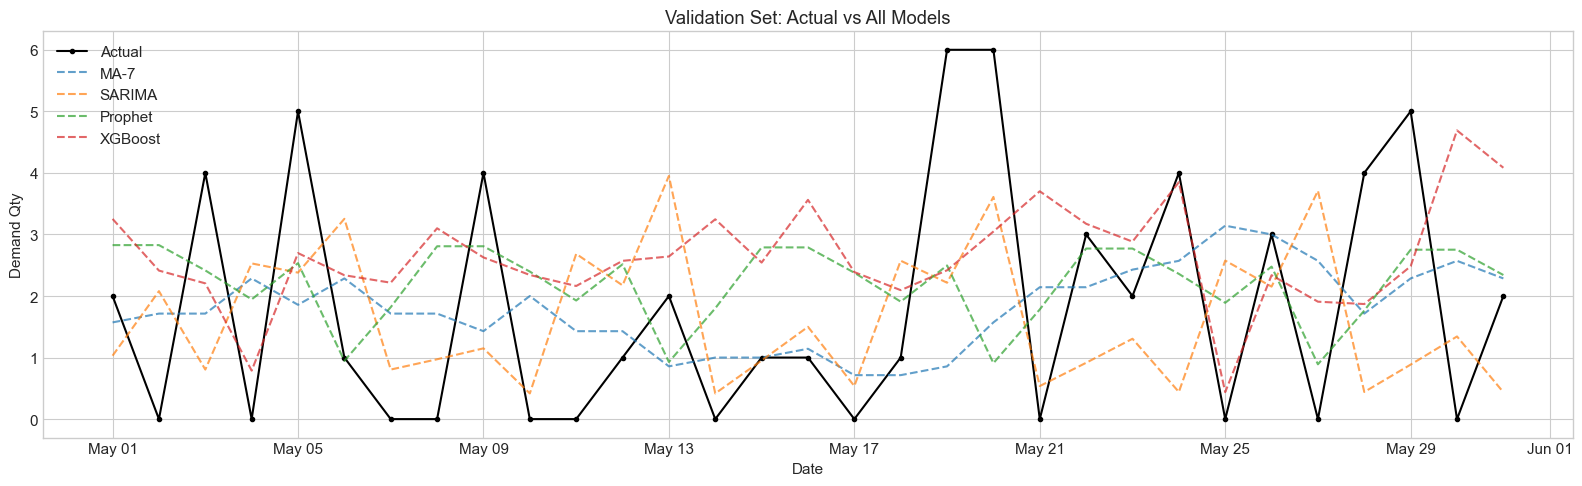

In [87]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(valFrame['ds'], valFrame['y'], 'k-o', markersize=3, label='Actual', linewidth=1.5)
ax.plot(valFrame['ds'], valFrame['predMA'], '--', label='MA-7', alpha=0.7)
ax.plot(valFrame['ds'], valFrame['predSARIMA'], '--', label='SARIMA', alpha=0.7)
ax.plot(valFrame['ds'], valFrame['predProphet'], '--', label='Prophet', alpha=0.7)
ax.plot(valFrame['ds'], valFrame['predXGB'], '--', label='XGBoost', alpha=0.7)
ax.set_title('Validation Set: Actual vs All Models')
ax.set_xlabel('Date'); ax.set_ylabel('Demand Qty')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout(); plt.show()

### Residual Analysis
Jika residual punya pola (error besar di weekend), model belum capture seasonality.

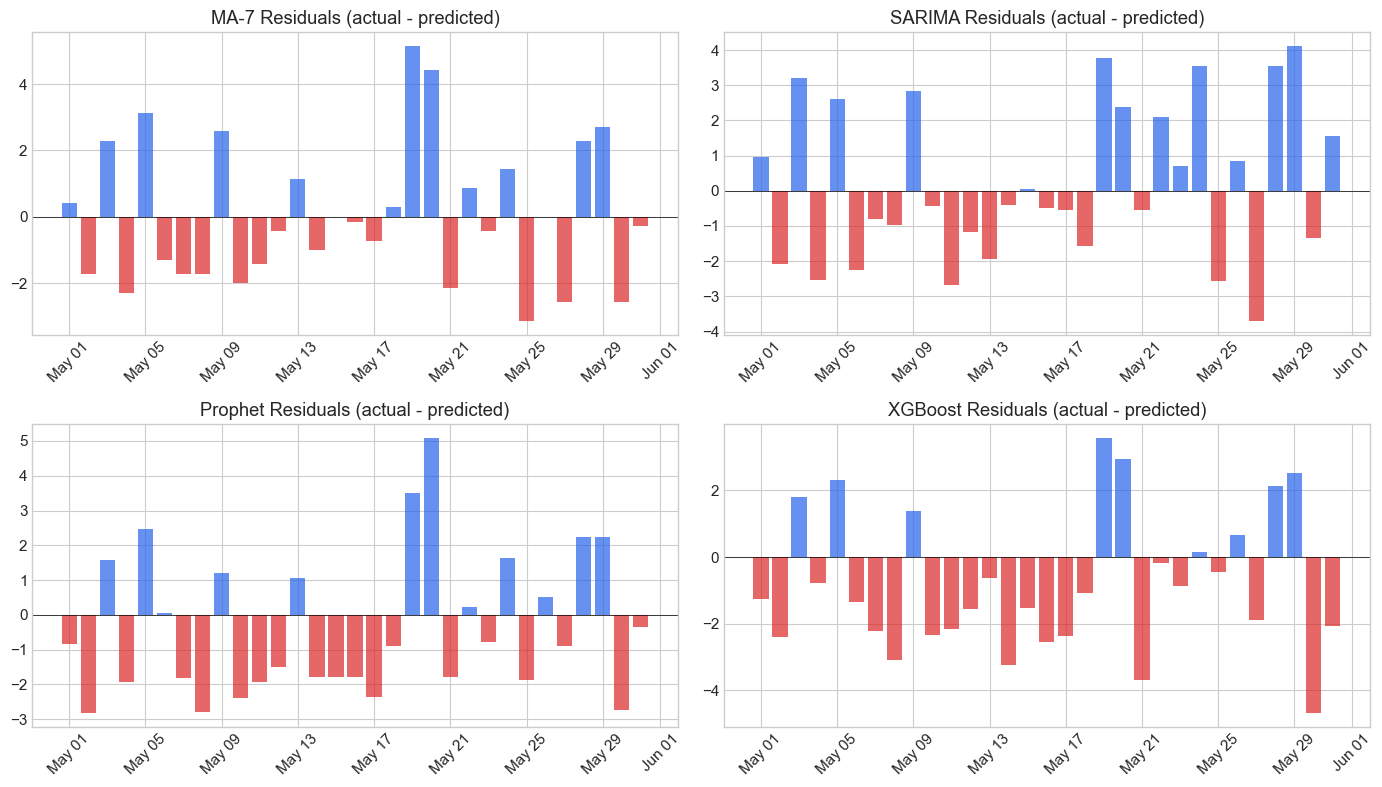

In [88]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
models = [('MA-7','predMA'), ('SARIMA','predSARIMA'), ('Prophet','predProphet'), ('XGBoost','predXGB')]
for ax, (name, col) in zip(axes.flat, models):
    resid = valFrame['y'].values - valFrame[col].values
    ax.bar(valFrame['ds'], resid, color=np.where(resid > 0, '#2563EB', '#DC2626'), alpha=0.7, width=0.8)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'{name} Residuals (actual - predicted)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

---
## 6. Business Impact Simulation & Model Export
### Waste Reduction Simulation
Translate MAPE → business metric (% waste reduction)

In [89]:
def simulateWaste(forecastQty, actualQty, safetyMargin=1.1):
    """Simulate waste: order = forecast * safety margin, waste = max(0, order - actual)"""
    ordered = np.maximum(forecastQty * safetyMargin, 1)
    waste = np.maximum(ordered - actualQty, 0)
    return waste.sum()

actualQty = valFrame['y'].values
wasteMA = simulateWaste(valFrame['predMA'].values, actualQty)
wasteSARIMA = simulateWaste(valFrame['predSARIMA'].values, actualQty)
wasteProphet = simulateWaste(valFrame['predProphet'].values, actualQty)
wasteXGB = simulateWaste(valFrame['predXGB'].values, actualQty)

# Naive: order fixed amount (mean of train)
wasteNaive = simulateWaste(np.full(len(actualQty), trainFrame['y'].mean()), actualQty)

print("═" * 60)
print("BUSINESS IMPACT: Waste Reduction vs Naive Fixed-Order")
print("═" * 60)
for name, w in [('MA-7', wasteMA), ('SARIMA', wasteSARIMA), ('Prophet', wasteProphet), ('XGBoost', wasteXGB)]:
    reduction = (wasteNaive - w) / wasteNaive * 100 if wasteNaive > 0 else 0
    print(f"  {name:12s}: waste={w:6.1f} units, reduction={reduction:+.1f}%")
print(f"  {'Naive fixed':12s}: waste={wasteNaive:6.1f} units (baseline)")

════════════════════════════════════════════════════════════
BUSINESS IMPACT: Waste Reduction vs Naive Fixed-Order
════════════════════════════════════════════════════════════
  MA-7        : waste=  29.4 units, reduction=+29.0%
  SARIMA      : waste=  31.3 units, reduction=+24.5%
  Prophet     : waste=  37.6 units, reduction=+9.4%
  XGBoost     : waste=  49.3 units, reduction=-18.8%
  Naive fixed : waste=  41.5 units (baseline)


### Model Selection & Export (.pkl)

In [90]:
# Select best model based on validation MAPE
bestRow = comparisonFrame.loc[comparisonFrame['MAPE_%'].idxmin()]
print(f"Selected model: {bestRow['Model']} (MAPE: {bestRow['MAPE_%']}%)")

# Export best model
if 'XGBoost' in bestRow['Model']:
    exportPath = modelDir / 'demandForecastXGB.pkl'
    joblib.dump({'model': xgbModel, 'features': featCols, 'skuId': topSkuId,
                 'metrics': metricsXGB}, exportPath)
elif 'Prophet' in bestRow['Model']:
    exportPath = modelDir / 'demandForecastProphet.pkl'
    joblib.dump({'model': prophetModel, 'skuId': topSkuId,
                 'metrics': metricsProphet}, exportPath)
elif 'SARIMA' in bestRow['Model']:
    exportPath = modelDir / 'demandForecastSARIMA.pkl'
    joblib.dump({'model': sarimaFit, 'skuId': topSkuId,
                 'metrics': metricsSARIMA}, exportPath)
else:
    exportPath = modelDir / 'demandForecastBaseline.pkl'
    joblib.dump({'method': 'MA-7', 'lastValues': list(trainFrame['y'].tail(7)),
                 'skuId': topSkuId, 'metrics': metricsMA}, exportPath)

print(f"Model exported to: {exportPath}")
print(f"\nNext: Load this .pkl in FastAPI backend for /api/forecast endpoint")

Selected model: SARIMA(1,1,1)(1,1,0,7) (MAPE: 2.7032781910658074e+17%)
Model exported to: /Users/ghazy/Documents/BrewStock/ml/forecast/models/demandForecastSARIMA.pkl

Next: Load this .pkl in FastAPI backend for /api/forecast endpoint


---
## Summary

| # | Model | Peran |
|---|-------|-------|
| M1 | Moving Average (7-day) | Baseline wajib |
| M2 | SARIMA(1,1,1)(1,1,0,7) | Statistical benchmark |
| M3 | Prophet | ML interpretable |
| M4 | XGBoost + lag features | ML high-performance |

**Golden thread:** EDA → feature engineering → model comparison → best model → .pkl export → FastAPI

**LSTM/GRU skipped** — data sintetis 6 bulan tidak cukup untuk justify deep learning.